In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12,6)

master = pd.read_csv(
    "../data/master_dataset.csv"
)

master["timestamp"] = pd.to_datetime(
    master["timestamp"]
)

print(master.shape)
master.head()

(2128152, 24)


,timestamp,grid,occupancy,duration,num,count,fast_count,slow_count,area,lon,...,hour,dayofweek,month,weekend,utilization,occ_lag_1,occ_lag_12,occ_lag_24,rolling_mean_12,rolling_mean_24
0,2024-01-01 02:05:00,102,12,0.75,1,30,3,27,0.71,114.103,...,2,0,1,0,0.0625,12.0,12.0,12.0,12.0,12.0
1,2024-01-01 02:10:00,102,12,0.75,1,30,3,27,0.71,114.103,...,2,0,1,0,0.0625,12.0,12.0,12.0,12.0,12.0
2,2024-01-01 02:15:00,102,12,0.75,1,30,3,27,0.71,114.103,...,2,0,1,0,0.0625,12.0,12.0,12.0,12.0,12.0
3,2024-01-01 02:20:00,102,12,0.75,1,30,3,27,0.71,114.103,...,2,0,1,0,0.0625,12.0,12.0,12.0,12.0,12.0
4,2024-01-01 02:25:00,102,12,0.75,1,30,3,27,0.71,114.103,...,2,0,1,0,0.0625,12.0,12.0,12.0,12.0,12.0


In [2]:
master.isnull().sum().sort_values(
    ascending=False
).head(20)

timestamp          0
grid               0
rolling_mean_12    0
occ_lag_24         0
occ_lag_12         0
occ_lag_1          0
utilization        0
weekend            0
month              0
dayofweek          0
hour               0
time_step          0
dynamic_pricing    0
CBD                0
la                 0
lon                0
area               0
slow_count         0
fast_count         0
count              0
dtype: int64

# Plot 1: Hourly Demand Pattern

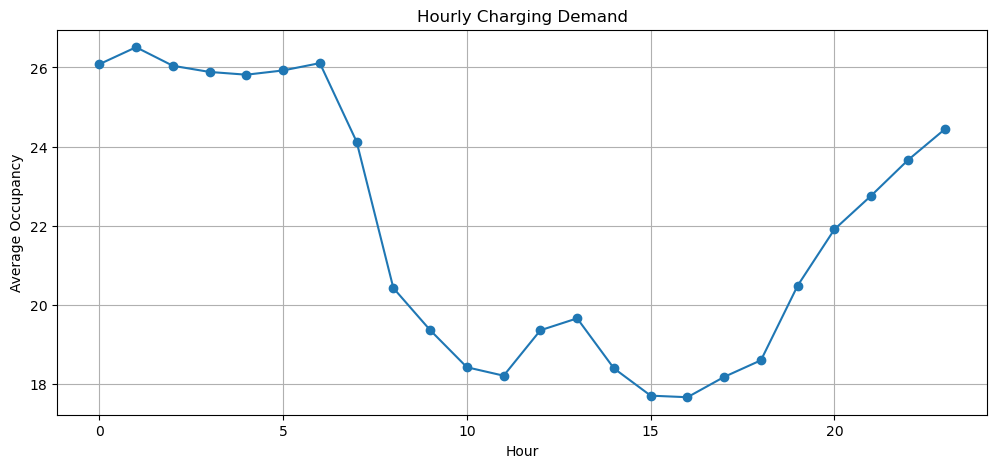

In [3]:
hourly = (master.groupby("hour")["occupancy"].mean())

plt.figure(figsize=(12,5))

plt.plot(hourly.index, hourly.values, marker='o')

plt.xlabel("Hour")
plt.ylabel("Average Occupancy")
plt.title("Hourly Charging Demand")

plt.grid()
plt.show()

In [4]:
master.groupby(
    "weekend"
)["occupancy"].mean()

weekend
0    21.740384
1    22.310803
Name: occupancy, dtype: float64

# Plot 2: Daily Demand

In [5]:
daily = (
    master.groupby(
        master["timestamp"].dt.date
    )["occupancy"]
    .mean()
)

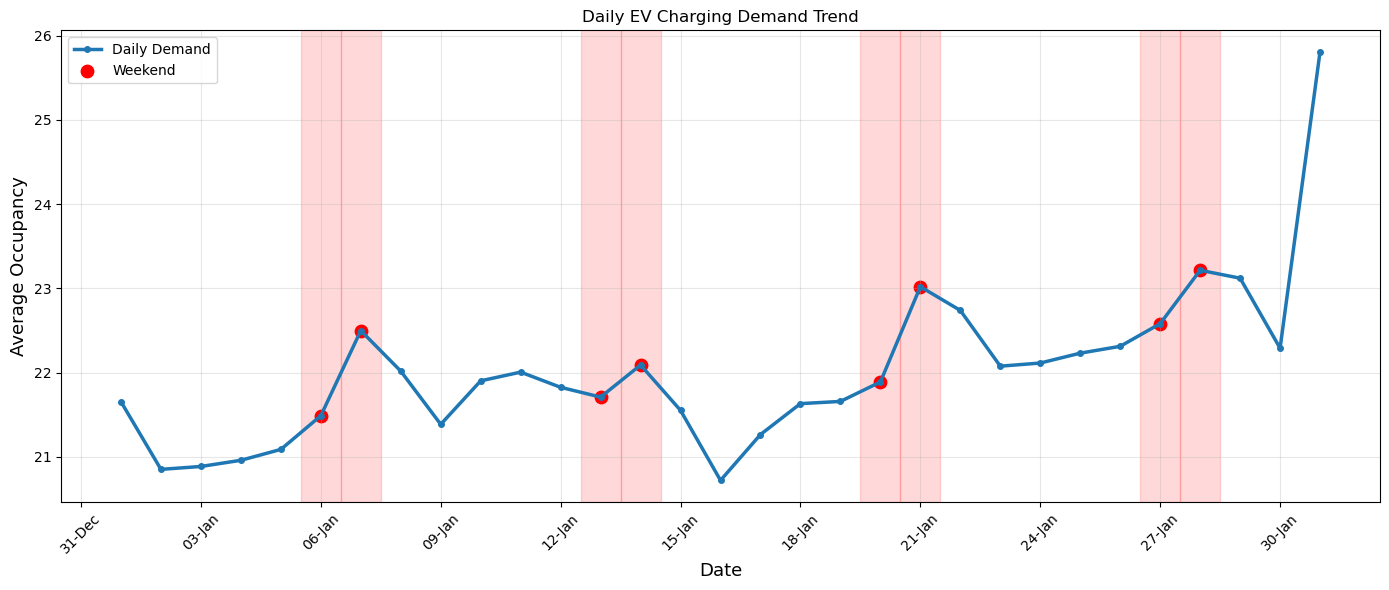

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Daily average occupancy
daily = (
    master.groupby(
        master["timestamp"].dt.date
    )["occupancy"]
    .mean()
)

daily.index = pd.to_datetime(daily.index)

# Weekend dates
weekend_mask = daily.index.dayofweek >= 5

plt.figure(figsize=(14,6))

# Main line
plt.plot(
    daily.index,
    daily.values,
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Daily Demand"
)

# Weekend markers
plt.scatter(
    daily.index[weekend_mask],
    daily.values[weekend_mask],
    color="red",
    s=80,
    label="Weekend"
)

plt.title(
    "Daily EV Charging Demand Trend",
)

plt.xlabel("Date", fontsize=13)
plt.ylabel("Average Occupancy", fontsize=13)

plt.gca().xaxis.set_major_locator(
    mdates.DayLocator(interval=3)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%d-%b")
)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

for day in daily.index[weekend_mask]:
    plt.axvspan(
        day - pd.Timedelta(hours=12),
        day + pd.Timedelta(hours=12),
        alpha=0.15,
        color="red"
    )

plt.show()

# Plot 3: Demand by Day & Hour Heatmap

In [17]:
master["day_name"] = master["dayofweek"].map({
    0:"Mon",
    1:"Tue",
    2:"Wed",
    3:"Thu",
    4:"Fri",
    5:"Sat",
    6:"Sun"
})

In [18]:
print(master["day_name"].value_counts())

day_name
Tue    355680
Mon    349505
Wed    284791
Thu    284544
Fri    284544
Sat    284544
Sun    284544
Name: count, dtype: int64


In [19]:
heatmap_data = master.pivot_table(
    values="occupancy",
    index="day_name",
    columns="hour",
    aggfunc="mean"
)

In [21]:
heatmap_data = heatmap_data.reindex(
    ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
)

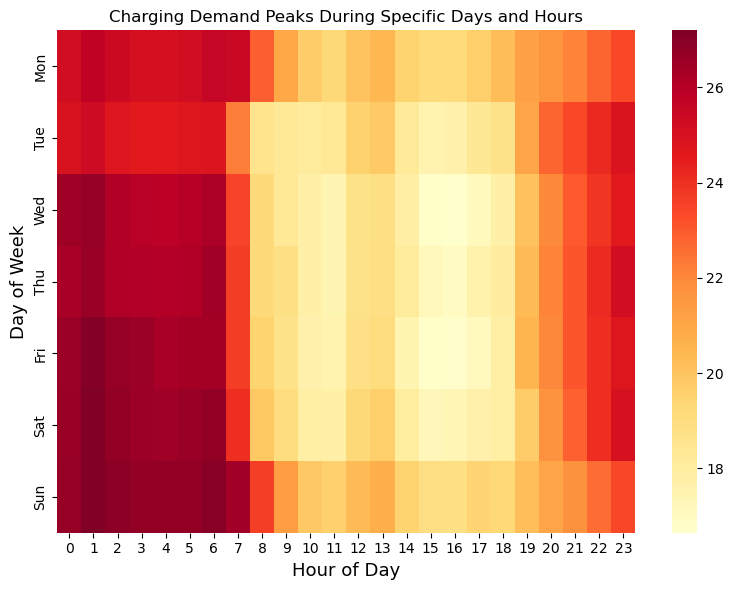

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap="YlOrRd"
)

plt.title(
    "Charging Demand Peaks During Specific Days and Hours",
)

plt.xlabel(
    "Hour of Day",
    fontsize=13
)

plt.ylabel(
    "Day of Week",
    fontsize=13
)

plt.tight_layout()

plt.show()

In [43]:
peak = heatmap_data.stack().idxmax()
peak_value = heatmap_data.stack().max()

print(
    f"Peak Demand: {peak} -> {peak_value:.2f}"
)

Peak Demand: ('Sun', 1) -> 27.20


# Plot 4: Top Stations

In [44]:
station_occ = (
    master.groupby("grid")["occupancy"]
    .mean()
    .sort_values(ascending=False)
)

In [45]:
cum_pct = (
    station_occ.cumsum()
    /
    station_occ.sum()
    * 100
)

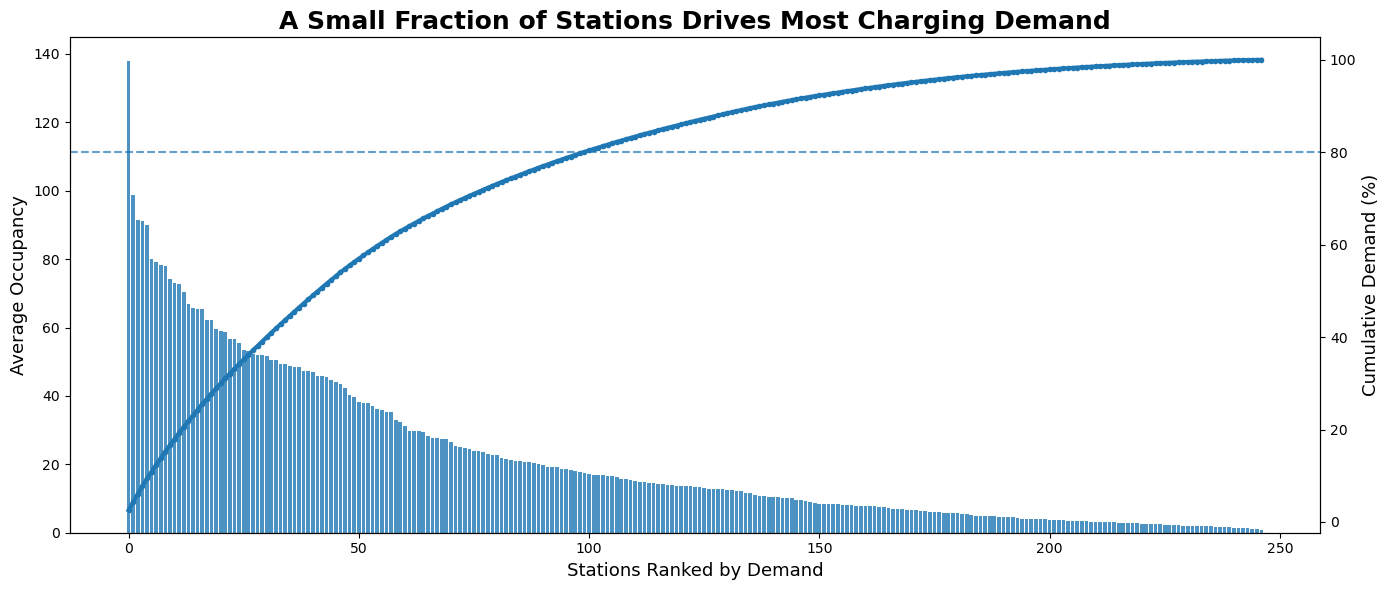

In [51]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Bars
ax1.bar(
    range(len(station_occ)),
    station_occ.values,
    alpha=0.8
)

ax1.set_xlabel(
    "Stations Ranked by Demand",
    fontsize=13
)

ax1.set_ylabel(
    "Average Occupancy",
    fontsize=13
)

# Cumulative %
ax2 = ax1.twinx()

ax2.plot(
    range(len(cum_pct)),
    cum_pct.values,
    linewidth=3,
    marker="o",
    markersize=3
)

ax2.set_ylabel(
    "Cumulative Demand (%)",
    fontsize=13
)

ax2.axhline(
    y=80,
    linestyle="--",
    alpha=0.7
)

plt.title(
    "A Small Fraction of Stations Drives Most Charging Demand",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [50]:
threshold_station = (
    cum_pct >= 80
).idxmax()

rank_80 = (
    station_occ.index
    .get_loc(threshold_station)
    + 1
)

print(
    f"{rank_80} stations generate 80% of total demand."
)

100 stations generate 80% of total demand.


Only 100 out of 247 charging stations account for 80% of network demand, suggesting that dynamic pricing efforts can be concentrated on a relatively small subset of locations.

# Top-20 Charging Stations

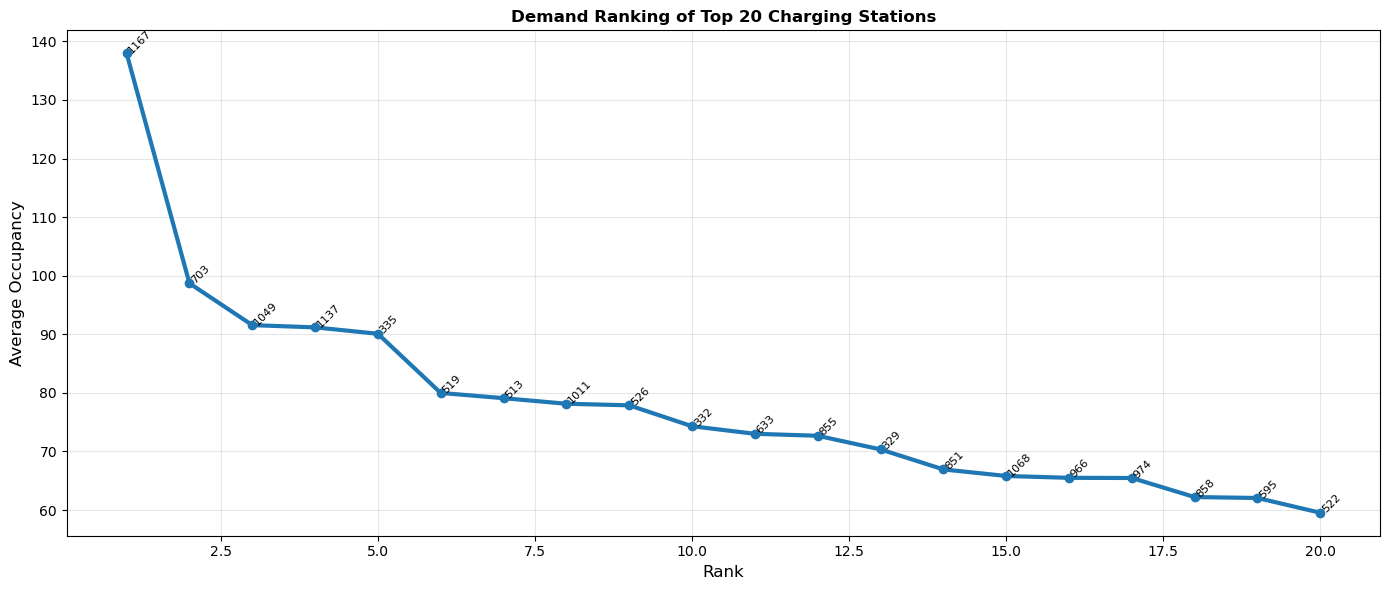

In [28]:
top20 = (
    master.groupby("grid")["occupancy"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(14,6))

plt.plot(
    range(1,21),
    top20.values,
    marker="o",
    linewidth=3
)

for i, (station, occ) in enumerate(top20.items(), start=1):
    plt.annotate(
        station,
        (i, occ),
        fontsize=8,
        rotation=45
    )

plt.title(
    "Demand Ranking of Top 20 Charging Stations",
    fontweight="bold"
)

plt.xlabel(
    "Rank",
    fontsize=12
)

plt.ylabel(
    "Average Occupancy",
    fontsize=12
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 5: CBD vs Non-CBD

In [29]:
master.groupby(
    "CBD"
)["occupancy"].mean()

CBD
0    22.557661
1    19.909416
Name: occupancy, dtype: float64

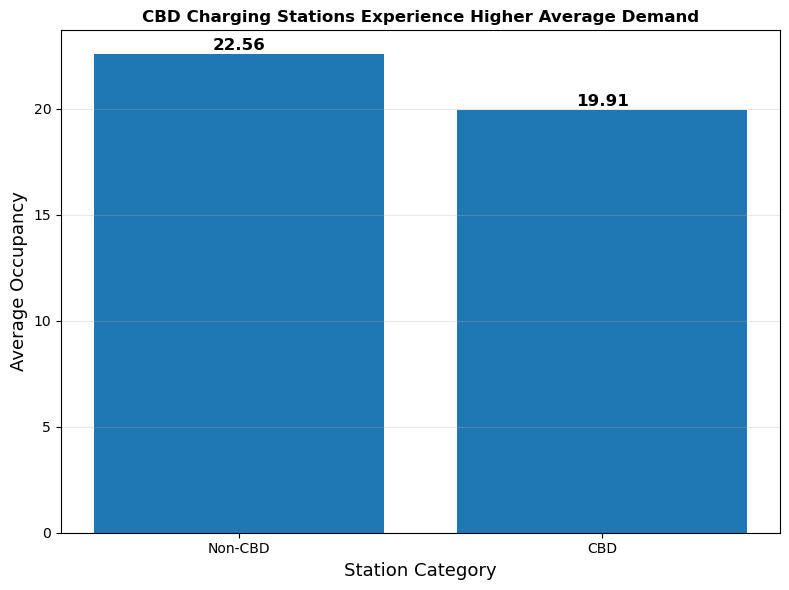

In [31]:
cbd_demand = (
    master.groupby("CBD")["occupancy"]
    .mean()
    .reset_index()
)

cbd_demand["Location Type"] = (
    cbd_demand["CBD"]
    .map({
        0:"Non-CBD",
        1:"CBD"
    })
)

plt.figure(figsize=(8,6))

bars = plt.bar(
    cbd_demand["Location Type"],
    cbd_demand["occupancy"]
)

# value labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.2f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "CBD Charging Stations Experience Higher Average Demand",
    fontweight="bold"
)

plt.ylabel(
    "Average Occupancy",
    fontsize=13
)

plt.xlabel(
    "Station Category",
    fontsize=13
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [32]:
cbd_mean = cbd_demand.loc[
    cbd_demand["CBD"] == 1,
    "occupancy"
].values[0]

non_mean = cbd_demand.loc[
    cbd_demand["CBD"] == 0,
    "occupancy"
].values[0]

uplift = (
    (cbd_mean - non_mean)
    / non_mean
) * 100

print(
    f"CBD Demand Uplift: {uplift:.1f}%"
)

CBD Demand Uplift: -11.7%


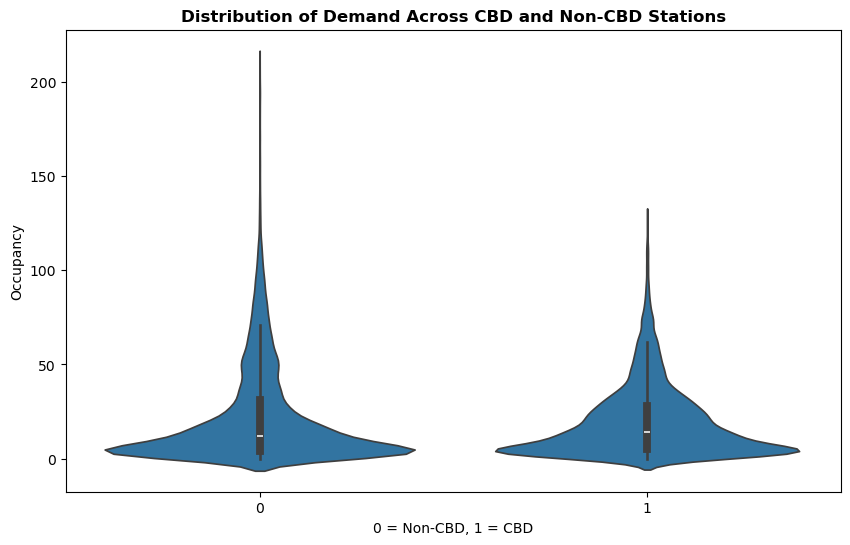

In [33]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=master.sample(50000),
    x="CBD",
    y="occupancy"
)

plt.title(
    "Distribution of Demand Across CBD and Non-CBD Stations",
    fontweight="bold"
)

plt.xlabel("0 = Non-CBD, 1 = CBD")
plt.ylabel("Occupancy")

plt.show()

# Plot 6: Spatial Demand Map

In [36]:
master.columns

Index(['timestamp', 'grid', 'occupancy', 'duration', 'num', 'count',
       'fast_count', 'slow_count', 'area', 'lon', 'la', 'CBD',
       'dynamic_pricing', 'time_step', 'hour', 'dayofweek', 'month', 'weekend',
       'utilization', 'occ_lag_1', 'occ_lag_12', 'occ_lag_24',
       'rolling_mean_12', 'rolling_mean_24', 'day_name'],
      dtype='object')

In [37]:
station_stats = (
    master.groupby("grid")
    .agg({
        "occupancy":"mean",
        "lon":"first",
        "la":"first"
    })
    .reset_index()
)

In [38]:
station_stats.head()

,grid,occupancy,lon,la
0,102,16.599698,114.1030,22.54041
1,105,13.863742,114.1208,22.55127
2,107,18.207289,114.1304,22.54486
3,108,13.741063,114.1315,22.55403
4,109,6.224930,114.1430,22.56388


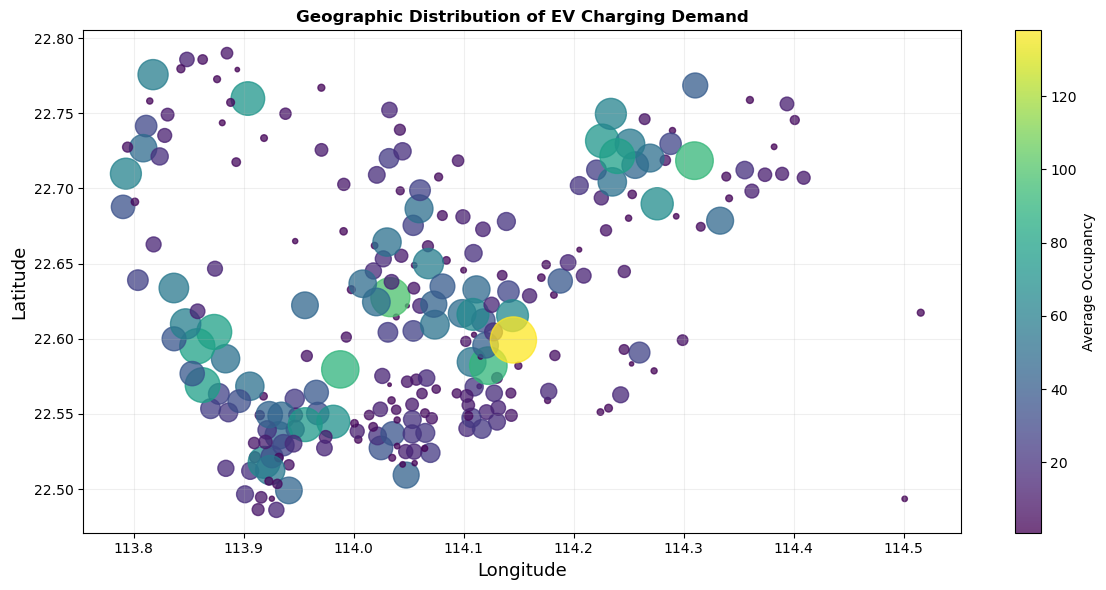

In [40]:
plt.figure(figsize=(12,6))

scatter = plt.scatter(
    station_stats["lon"],
    station_stats["la"],
    s=station_stats["occupancy"] * 8,
    c=station_stats["occupancy"],
    alpha=0.75
)

plt.colorbar(
    scatter,
    label="Average Occupancy"
)

plt.title(
    "Geographic Distribution of EV Charging Demand",
    fontweight="bold"
)

plt.xlabel(
    "Longitude",
    fontsize=13
)

plt.ylabel(
    "Latitude",
    fontsize=13
)

plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()

In [41]:
top5_geo = (
    station_stats
    .sort_values(
        "occupancy",
        ascending=False
    )
    .head(5)
)

top5_geo

,grid,occupancy,lon,la
242,1167,137.955316,114.1453,22.59922
95,703,98.709030,114.0334,22.62769
183,1049,91.558496,114.3099,22.71846
229,1137,91.177344,114.1225,22.58215
38,335,90.083565,113.9879,22.57965
